In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Class Imbalance

In [ ]:
# https://dontpad.com/bcc-ds-02

df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/imbalanced.csv')

In [ ]:
df.head(3)

,attrib1,attrib2,attrib3,class
0,1.595781,5.540723,9.109505,groupA
1,2.657896,1.166703,1.368305,groupA
2,0.901466,4.374227,3.207844,groupA


<Axes: xlabel='attrib1', ylabel='attrib2'>

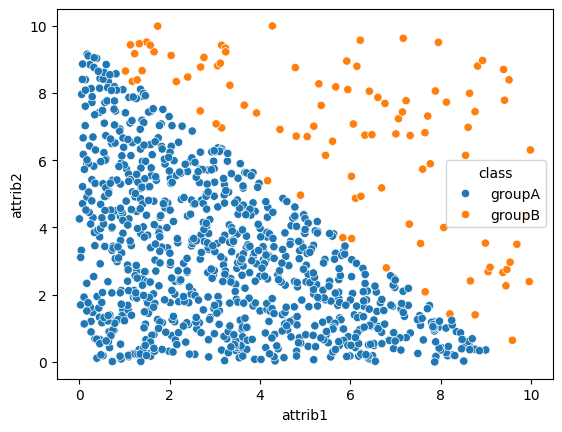

In [ ]:
# vamos criar um gráfico de dispersão
# e colorir os pontos conforme a classe
sns.scatterplot(x=df['attrib1'],
                y=df['attrib2'],
                hue=df['class'])

# o que conseguimos observar?
    # 1) Separabilidade razoável:
        # Há uma fronteira visual clara,
        # o que nos diz que um modelo linear,
        # como regressão logística, pode ter bom desempenho,
        # mesmo com desbalanceamento.
            # Os dados de groupA tendem a se concentrar
            # na parte inferior esquerda do gráfico.

            # Já groupB está mais presente
            # na parte superior direita.

    # 2) Um desequilíbrio de classe:
        # Visualmente, é claro que temos muito mais pontos
        # azuis (groupA) do que pontos laranja (groupB).

    # 3) Risco de viés do modelo:
        # Se treinarmos um modelo sem tratar o desbalanceamento,
        # ele pode simplesmente prever tudo como groupA
        # e ainda obter uma alta acurácia (por causa da proporção).

        # Isso seria um modelo enviesado,
        # que não aprendeu nada útil sobre a minoria (groupB).

In [ ]:
# vamos dividir em treino e teste
from sklearn.model_selection import train_test_split

# precisamos remover a classe
X, y = df.drop('class', axis=1), df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, stratify=y,
    random_state=123
)

In [ ]:
# modelo de regressão logística
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000,
                        random_state=123)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=123)

In [ ]:
# avaliação do modelo

from sklearn.metrics import accuracy_score

y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'acc: {acc:.4f}')

# acc: 0.9848
# Qual o problema aqui?
  # A acurácia pode ser enganosa em problemas desbalanceados
  # Exemplo: se 90% das amostras forem da classe A,
  # um modelo que sempre prever A terá 90% de acurácia,
  # mas não será útil!

acc: 0.9848


In [ ]:
# a gente já visualizou o desiquilíbrio de classes
# no gráfico de dispersão, mas vamos ver exatamente
# a porcentagem de amostras por classe no dataset

class_distribution = df['class'].value_counts(normalize=True) * 100
class_distribution

# ou seja, um classificador que sempre
# preveja a classe groupA vai ter
# mais de 90% de acurácia, concordam?

,proportion
class,
groupA,90.2
groupB,9.8


In [ ]:
# então vamos calcular outras métricas além da acurácia
# (coisa que vocês já viram na disciplina
# de Aprendizado de Máquina)

from sklearn.metrics import precision_score, recall_score, f1_score

prec = precision_score(y_test, y_pred, pos_label='groupB') # grupo minoritário
rec = recall_score(y_test, y_pred, pos_label='groupB')
f1 = f1_score(y_test, y_pred, pos_label='groupB')

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')

# precision = 1.0000
    # O modelo não predisse nenhum falso positivo
    # ao classificar instâncias como groupB.
        # Ou seja: todas as vezes que ele
        # previu groupB, estava certo.

        # Em outras palavras, o modelo é muito
        # conservador ao prever groupB
        # só faz isso quando tem muita certeza.

# recall = 0.8438
    # O modelo identificou corretamente 84.38%
    # das instâncias reais de groupB,
    # mas deixou escapar cerca de 15.6%.

    # Apesar da precisão perfeita, o modelo
    # não detectou todas as ocorrências reais
    # da classe minoritária. Em algumas aplicações,
    # como diagnóstico médico, isso pode ser perigoso:
        # imaginem não detectar 15% dos pacientes
        # com uma doença.

# F1-score = 0.9153
    # O F1-score é a média harmônica entre
    # precisão e recall

Accuracy:  0.9848
Precision: 1.0000
Recall:    0.8438
F1-score:  0.9153


In [ ]:
# OVERsampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# UNDERsampling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import NearMiss

In [ ]:
# vamos criar um dicionário
# com as técnicas de amostragem
samplers = {'RO': RandomOverSampler(random_state=123),
            'SMOTE': SMOTE(random_state=123),
            'RU': RandomUnderSampler(random_state=123),
            'NM1': NearMiss(version=1),
            'NM2': NearMiss(version=2),
            'NM3': NearMiss(version=3)}

In [ ]:
# agora vamos testar cada técnica

# para cada técnica:
for name, sampler in samplers.items():
    # aplica o balanceamento no CONJUNTO DE TREINO (fit_resample)
    X_sampled, y_sampled = sampler.fit_resample(X_train, y_train)

    # treina novamente um modelo de regressão logística
    lr = LogisticRegression(max_iter=1000, random_state=123)
    lr.fit(X_sampled, y_sampled)

    # avalia no MESMO conjunto de teste,
    # que não foi balanceado
    # (importante para uma avaliação justa).
    y_pred = lr.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_a = f1_score(y_test, y_pred, pos_label='groupA')
    f1_b = f1_score(y_test, y_pred, pos_label='groupB')
    f1_ab = np.mean((f1_a, f1_b))

    # imprimir os resultados
    print(f'{name}:\t acc: {acc:.4f} | f1: {f1_ab:.4f}')

RO:	 acc: 0.9818 | f1: 0.9521
SMOTE:	 acc: 0.9939 | f1: 0.9832
RU:	 acc: 0.9970 | f1: 0.9912
NM1:	 acc: 0.9848 | f1: 0.9535
NM2:	 acc: 0.9879 | f1: 0.9633
NM3:	 acc: 0.9848 | f1: 0.9535


In [ ]:
# vamos rodar N vezes e reportar a média + desvio padrão
# (já que há elementos aleatórios nos algoritmos)
# por praticidade, vamos reportar apenas o f1

dict_f1 = {'RO': [],
           'SMOTE': [],
           'RU': [],
           'NM1': [],
           'NM2': [],
           'NM3': []}

num_runs = 10
for idx_run in range(num_runs):
    print(f'run: {idx_run+1}')
    samplers = {'RO': RandomOverSampler(),
                'SMOTE': SMOTE(),
                'RU': RandomUnderSampler(),
                'NM1': NearMiss(version=1),
                'NM2': NearMiss(version=2),
                'NM3': NearMiss(version=3)}

    # para cada técnica:
    for name, sampler in samplers.items():
        # aplica o balanceamento no CONJUNTO DE TREINO (fit_resample)
        X_sampled, y_sampled = sampler.fit_resample(X_train, y_train)

        # treina novamente um modelo de regressão logística
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_sampled, y_sampled)

        # avalia no MESMO conjunto de teste,
        # que não foi balanceado (importante para uma avaliação justa).
        y_pred = lr.predict(X_test)

        # acc = accuracy_score(y_test, y_pred)
        f1_a = f1_score(y_test, y_pred, pos_label='groupA')
        f1_b = f1_score(y_test, y_pred, pos_label='groupB')
        f1_ab = np.mean((f1_a, f1_b))

        # imprime os resultados
        print(f"  {name + ':':6} {f1_ab:.4f}")
        dict_f1[name].append(f1_ab)

    print()

print(f'Mean Results ({num_runs} runs)')
for sampler in dict_f1:
  print(f"  {sampler + ':':6} {np.mean(dict_f1[sampler]):.4f} +- {np.std(dict_f1[sampler]):.4f}")

run: 1
  RO:    0.9672
  SMOTE: 1.0000
  RU:    0.9672
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 2
  RO:    0.9521
  SMOTE: 0.9912
  RU:    0.9307
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 3
  RO:    0.9521
  SMOTE: 0.9822
  RU:    0.9508
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 4
  RO:    0.9751
  SMOTE: 0.9912
  RU:    0.9448
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 5
  RO:    0.9448
  SMOTE: 0.9912
  RU:    0.9595
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 6
  RO:    1.0000
  SMOTE: 0.9912
  RU:    0.9573
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 7
  RO:    0.9521
  SMOTE: 1.0000
  RU:    0.8922
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 8
  RO:    0.9376
  SMOTE: 0.9912
  RU:    0.9108
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 9
  RO:    0.9751
  SMOTE: 1.0000
  RU:    0.8922
  NM1:   0.9535
  NM2:   0.9633
  NM3:   0.9535

run: 10
  RO:    0.9672
  SMOTE: 0.9912
  RU:    0.8982
  NM1:  

In [ ]:
# O SMOTE se saiu melhor! (99%)
    # Nesse caso, as estratégias de oversampling
    # superaram as estratégias de undersampling!

Além das técnicas de amostragem, outra estratégia comum é usar **class weights** (pesos de classe). Nesse caso, damos maior importância às classes sub-representadas durante o treinamento, tornando erros nessas classes mais custosos.

**Importante**: isso NÃO altera a quantidade de amostras no dataset; apenas muda o peso de cada classe na função de perda.

# Hypothesis Testing

In [ ]:
# Vamos importar todas as bibliotecas, mas
# não vamos usar todas necessariamente.

# parametric
# paired t-test
from scipy.stats import ttest_rel # t-test related

# unpaired t-test
from scipy.stats import ttest_ind # t-test independent

# non-parametric
# wilcoxon test (paired)
from scipy.stats import wilcoxon

# mann-whitney u test (unpaired)
from scipy.stats import mannwhitneyu

In [ ]:
df = pd.read_csv('https://raysonlaroca.github.io/' +
                 'teaching/data-science/datasets/salaries.csv')

In [ ]:
df.head(3)

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750


In [ ]:
# Hipótese:
  # os salários das mulheres são
  # significativamente menores que os dos homens

# dois pontos a analisar:
  # 1) teste pareado ou não?
  # 2) teste paramétrico ou não paramétrico?

In [ ]:
# 1) teste pareado ou não?

# um bom ponto de partida para responder se
# o teste deve ser pareado ou não é usar um value_counts()
df['sex'].value_counts()
    # O número de homens e mulheres é bastante desequilibrado.

    # Portanto, o teste adequado é não pareado.

    # Importante: o critério para aplicar um
    # teste pareado não é apenas a quantidade
    # de elementos, mas sim a existência de um
    # pareamento natural entre as observações,
    # ou seja, um mapeamento 1:1.

    # exemplo prático:
        # Se cada mulher está sendo comparada diretamente
        # com um homem (na mesma função, mesma empresa, etc.),
        # então o teste pode ser pareado.

    # Caso contrário, como em comparações gerais entre
    # grupos de homens e mulheres independentes, o teste é
    # não pareado (mais comum neste tipo de análise salarial).

,count
sex,
Male,358
Female,39


In [ ]:
# 2) teste paramétrico ou não paramétrico?
# Essa determinação depende
# do comportamento das variáveis envolvidas
    # Se os salários forem normalmente distribuídos
    # e tiverem variâncias similares,
    # pode-se usar um teste paramétrico (como o t de Student).

    # Se a distribuição não for normal
    # ou houver outliers ou heterocedasticidade (diferença nas variâncias),
    # o mais apropriado é um teste não paramétrico,
    # como o teste de Mann-Whitney U

# Então, vamos plotar a distribuição da variável sexo
    # Precisamos fazer isso tanto para homens
    # quanto para mulheres

salarios_homens = df[df['sex'] == 'Male']['salary']
salarios_mulheres = df[df['sex'] == 'Female']['salary']

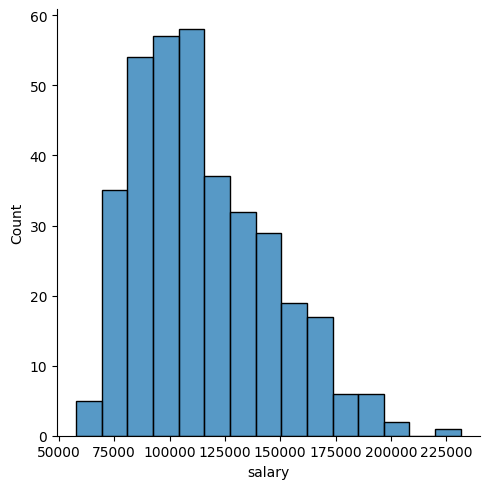

In [ ]:
sns.displot(salarios_homens)

# Não segue uma distribuição normal.
    # A distribuição é assimétrica à direita

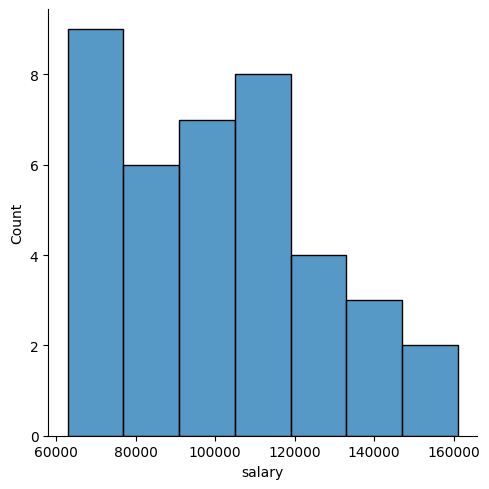

In [ ]:
sns.displot(salarios_mulheres)

# Também não segue uma distribuição normal.
  # A distribuição apresenta múltiplos picos,
  # o que sugere heterogeneidade no grupo.

  # Também é assimétrica e não apresenta simetria
  # ou forma de sino clara.

In [ ]:
# Não conseguimos verificar a normalidade nos dados
# Resposta: teste não paramétrico!

In [ ]:
# Como as distribuições salariais
# não seguem um padrão normal (Gaussiano),
# optamos por um teste não paramétrico:
# o teste de Mann-Whitney U.

# Aplicação do teste de Mann-Whitney U (amostras independentes)
_, p = mannwhitneyu(salarios_homens, salarios_mulheres)

# Interpretação do valor-p
if p > 0.05:
    print(f'Não há diferença estatisticamente significativa (p = {p:.4f})')
else:
    print(f'Há diferença estatisticamente significativa (p = {p:.4f})')

Há diferença estatisticamente significativa (p = 0.0082)


## Contexto de machine learning

In [ ]:
from sklearn.datasets import make_classification

# vamos usar a função make_classification
# para gerar um dataset sintético
# que pode ser usado para classificação
X, y = make_classification(n_samples=10000,
                           n_features=50,
                           n_informative=5,
                           n_redundant=5,
                           n_repeated=5,
                           n_classes=3,
                           random_state=123)

In [ ]:
# vamos treinar 3 classificadores

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# vamos instanciar
lr = LogisticRegression(max_iter=1000, random_state=123)
dt = DecisionTreeClassifier(random_state=123)
knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# StratifiedKFold: divide os dados em k partes (folds),
# preservando a proporção de classes em cada dobra
# (muito útil quando as classes estão desbalanceadas).

skf = StratifiedKFold(n_splits=10,
                      shuffle=True,
                      random_state=123)

resultados = []

for train_index, test_index in skf.split(X, y):
    # divide os dados em treino e teste
    # com base nos índices fornecidos pelo skf
    X_train, y_train = X[train_index], y[train_index]
    X_test, y_test = X[test_index], y[test_index]

    # treino dos 3 classificadores
    lr.fit(X_train, y_train)
    dt.fit(X_train, y_train)
    knn.fit(X_train, y_train)

    # predições e estimativa de acurácia
    acc_lr = accuracy_score(y_test, lr.predict(X_test))
    acc_dt = accuracy_score(y_test, dt.predict(X_test))
    acc_knn = accuracy_score(y_test, knn.predict(X_test))

    linha = {'lr': acc_lr, 'dt': acc_dt, 'knn': acc_knn}
    resultados.append(linha)

# converte a lista de dicionários
# em um DataFrame do pandas
resultados = pd.DataFrame(resultados)
resultados

,lr,dt,knn
0,0.537,0.752,0.761
1,0.596,0.771,0.793
2,0.566,0.781,0.753
3,0.548,0.764,0.754
4,0.527,0.782,0.764
5,0.544,0.767,0.745
6,0.566,0.784,0.751
7,0.543,0.780,0.741
8,0.561,0.786,0.749
9,0.549,0.776,0.755


In [ ]:
resultados.describe()

# na média, qual foi melhor?
    # R: DT (com 77.43%)

,lr,dt,knn
count,10.000000,10.00000,10.000000
mean,0.553700,0.77430,0.756600
std,0.019437,0.01074,0.014485
min,0.527000,0.75200,0.741000
25%,0.543250,0.76800,0.749500
50%,0.548500,0.77800,0.753500
75%,0.564750,0.78175,0.759500
max,0.596000,0.78600,0.793000


In [ ]:
# Nesse caso, a pergunta que vai surgir é:
    # o DT é significativamente melhor que o KNN, estatisticamente falando?

# A primeira pergunta que temos que fazer é:
    # 1) Esse problema é pareado ou não pareado?
        # R: é um problema pareado!
        # Como sabemos disso?
            # Os dados de treino e de teste
            # são iguais para todos os modelos
            # em cada uma das 10 execuções!

            # lr.fit(X_train, y_train)
            # dt.fit(X_train, y_train)
            # knn.fit(X_train, y_train)

In [ ]:
# A segunda pergunta que temos que fazer é:
    # 2) Esse problema é paramétrico ou não paramétrico
        # Para responder essa pergunta,
        # temos que olhar a distribuição dos resultados!

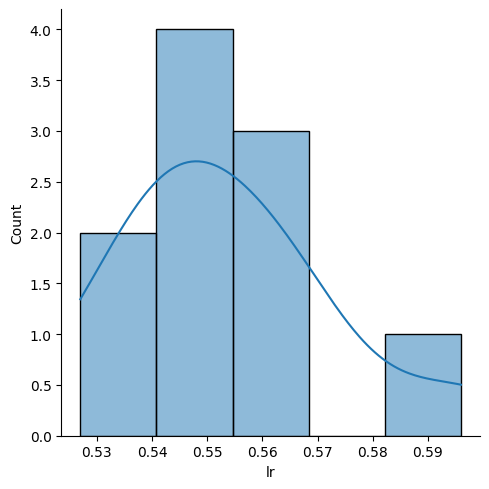

In [ ]:
sns.displot(resultados['lr'], kde=True)

# Não tenho certeza que isso é uma distribuição normal/gaussiana
# então seguimos com testes não paramétricos!
    # temos poucos dados! (apenas 10 execuções)
        # em dúvida, utilizar um teste não paramétrico!

In [ ]:
# A questão é que estes testes só permitem
# comparar dois classificadores por vez.

# então, vamos rodar dois testes:
  # 1) LR vs. DT
  # 2) DT vs. KNN

# LR vs. DT (99%)
_, p = wilcoxon(resultados['lr'], resultados['dt'])

print('LR vs. DT')

# Interpretação do valor-p
if p > 0.01:
    print(f'  Não há diferença estatisticamente significativa (p = {p:.4f})')
else:
    print(f'  Há diferença estatisticamente significativa (p = {p:.4f})')

LR vs. DT
Há diferença estatisticamente significativa (p = 0.0020)


In [ ]:
# LR vs. KNN (99%)
_, p = wilcoxon(resultados['dt'], resultados['knn'])

print('DT vs. KNN')

# Interpretação do valor-p
if p > 0.01:
    print(f'  Não há diferença estatisticamente significativa (p = {p:.4f})')
else:
    print(f'  Há diferença estatisticamente significativa (p = {p:.4f})')

DT vs. KNN
Não há diferença estatisticamente significativa (p = 0.0293)


### Friedman + Nemenyi

In [ ]:
# O teste de Friedman é usado para comparar
# 3 ou mais métodos (ex: classificadores)
# avaliados nos mesmos blocos (ex: folds).

from scipy.stats import friedmanchisquare

# vejam que a aplicação é a mesma
# a única diferença é que vamos passar os 3 modelos aqui
_, p = friedmanchisquare(resultados['lr'],
                         resultados['dt'],
                         resultados['knn'])

# Interpretação do valor-p
if p > 0.05: # 95% de confiança
    print(f'Não há diferença estatisticamente significativa (p = {p:.4f})')
else:
    print(f'Há diferença estatisticamente significativa (p = {p:.4f})')

Há diferença estatisticamente significativa (p = 0.0002)


In [ ]:
resultados

,lr,dt,knn
0,0.537,0.752,0.761
1,0.596,0.771,0.793
2,0.566,0.781,0.753
3,0.548,0.764,0.754
4,0.527,0.782,0.764
5,0.544,0.767,0.745
6,0.566,0.784,0.751
7,0.543,0.780,0.741
8,0.561,0.786,0.749
9,0.549,0.776,0.755


In [ ]:
from scipy.stats import rankdata

# Calcula o ranking de cada classificador
# em cada linha (ex: cada fold)

# Multiplicamos por -1 pois, neste caso,
# quanto maior o valor (ex: acurácia), melhor.

ranking = (resultados * -1).apply(lambda row: rankdata([row['lr'],
                                                        row['dt'],
                                                        row['knn']]), axis=1)
ranking

,0
0,"[3.0, 2.0, 1.0]"
1,"[3.0, 2.0, 1.0]"
2,"[3.0, 1.0, 2.0]"
3,"[3.0, 1.0, 2.0]"
4,"[3.0, 1.0, 2.0]"
5,"[3.0, 1.0, 2.0]"
6,"[3.0, 1.0, 2.0]"
7,"[3.0, 1.0, 2.0]"
8,"[3.0, 1.0, 2.0]"
9,"[3.0, 1.0, 2.0]"


In [ ]:
!pip install autorank

  Preparing metadata (setup.py) ... done
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18027 sha256=91c8da74884464302142ccd25a0c8fbe462fd90e531a15acbec74d2d448755cf
  Stored in directory: /root/.cache/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
Successfully built baycomp


Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
     meanrank  median     mad  ci_lower  ci_upper effect_size   magnitude  \
lr        3.0  0.5485   0.012   0.53567   0.57173         0.0  negligible   
knn       1.8  0.7535   0.006  0.743164  0.770036  -11.837283       large   
dt        1.2  0.7780  0.0065  0.764338  0.784262  -14.048771       large   

    effect_size_above magnitude_above  
lr                0.0      negligible  
knn        -11.837283           large  
dt          -1.388146           large  
The statistical analysis was conducted for 3 populations with 10 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We failed to reject the null hypothesis that the population is normal for all populations (minimal observed p-value=0.021). Therefore, we assume that all populations are normal.
We applied Bartlett's test for homogeneity and failed to reject the null hypothesis (p=0.231) that the data is

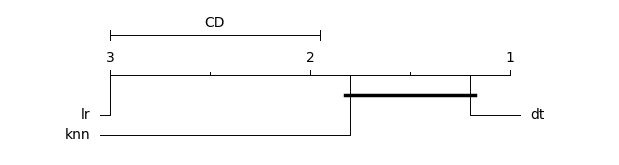

In [ ]:
from autorank import autorank, create_report, plot_stats

ranked_result = autorank(resultados,
                         order='descending',
                         alpha=0.05,
                         force_mode='nonparametric',
                         verbose=False)

# Gera um relatório textual
print(create_report(ranked_result))

# Mostra o gráfico com ranks e distâncias críticas
plot_stats(ranked_result)

# Exibe a Critical Distance
print(f"\nCritical Distance (CD): {ranked_result.cd:.3f}")

In [ ]:
# Conclusão:
    # dt é significativamente melhor que lr
    # knn também é significativamente melhor que lr
    # dt vs. knn: não há diferença significativa